In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
ref = pd.read_csv('../../data/mondo/mondo_references.csv').astype({'mondo_id':int}).astype({'mondo_id':str})
ref.shape

(134816, 3)

In [4]:
primekg = pd.read_csv('../../src/kg4rd/kg/auxillary/kg_giant.csv', low_memory=False)

In [5]:
orphanets = pd.merge(primekg.query('x_source == "MONDO"').drop_duplicates("x_id"), ref,'left', left_on='x_id', right_on='mondo_id').get([
    'mondo_id', 'ontology', 'ontology_id', 'x_name'
]).query('ontology == "Orphanet"')
orphanets.head()

,mondo_id,ontology,ontology_id,x_name
1,16045,Orphanet,199310,tetragametic chimerism
4,8959,Orphanet,1401,CHAND syndrome
14,16562,Orphanet,240094,progressive supranuclear palsy-pure akinesia w...
17,19308,Orphanet,79405,junctional epidermolysis bullosa inversa
22,19309,Orphanet,79406,late-onset junctional epidermolysis bullosa


In [6]:
all_orphanet_mondo_ids = orphanets.drop_duplicates('mondo_id')['mondo_id'].tolist()  # MONDO 中所有来自 Orphanet 的罕见病
len(all_orphanet_mondo_ids)

9135

In [7]:
filtered_data = primekg[primekg['x_id'].isin(all_orphanet_mondo_ids) & (primekg['x_source'] == 'MONDO')]
# 直接通过 groupby 统计所有关系
edges = filtered_data.groupby('relation').size().to_dict()
edges

{'contraindication': 3072,
 'disease_disease': 41415,
 'disease_phenotype_negative': 620,
 'disease_phenotype_positive': 152412,
 'disease_protein': 23332,
 'exposure_disease': 506,
 'indication': 1895,
 'off-label use': 575}

In [8]:
filtered_data.shape

(223827, 10)

In [9]:
edges_average = {k: round(v / len(all_orphanet_mondo_ids), 3) for k, v in edges.items()}
edges_average

{'contraindication': 0.336,
 'disease_disease': 4.534,
 'disease_phenotype_negative': 0.068,
 'disease_phenotype_positive': 16.684,
 'disease_protein': 2.554,
 'exposure_disease': 0.055,
 'indication': 0.207,
 'off-label use': 0.063}

9135
mean_value:  24.502134646962233
9116


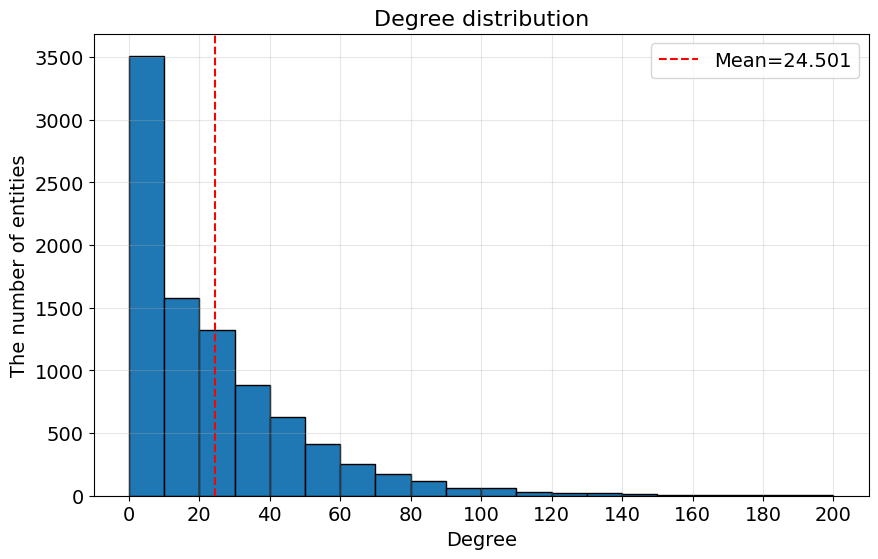

In [61]:
values = list(filtered_data.groupby('x_id').size().to_dict().values())
print(len(values))
mean_value = np.mean(values)
print("mean_value: ", mean_value)
values = [v for v in values if v <= 200]
print(len(values))

plt.figure(figsize=(10, 6))
plt.hist(values, bins=range(0, max(values)+10, 10), edgecolor='black')

plt.axvline(x=mean_value, color='red', linestyle='--', label=f'Mean=24.501')  # 24.502

plt.rcParams.update({'font.size': 14})  # 增加字体大小
plt.title('Degree distribution', fontsize=16)
plt.xlabel('Degree', fontsize=14)
plt.ylabel('The number of entities', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)

plt.xticks(range(0, max(values)+20, 20), fontsize=14)
plt.yticks(fontsize=14)

plt.savefig('../../papers/figures/primekg_orphanet_degree_distribution.png')
plt.show()


In [38]:
# Select three relation types and group by x_id
drug_disease = filtered_data.groupby(['x_id']).get_group('16045').groupby('relation').size().to_dict()
drug_disease

/tmp/ipykernel_119067/2261074592.py:2: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  drug_disease = filtered_data.groupby(['x_id']).get_group('16045').groupby('relation').size().to_dict()


{'disease_disease': 1,
 'disease_phenotype_negative': 1,
 'disease_phenotype_positive': 16}

In [ ]:
all_x_relations = {}
x_ids = filtered_data['x_id'].unique().tolist()
for i, x_id in enumerate(x_ids):
    print(f"{i}/{len(x_ids)}", end="\r")
    relations = filtered_data[filtered_data['x_id'] == x_id].groupby('relation').size().to_dict()
    all_x_relations[x_id] = relations

relations_df = pd.DataFrame.from_dict(all_x_relations, orient='index').fillna(0)



,disease_disease,disease_phenotype_negative,disease_phenotype_positive,disease_protein,contraindication,indication,off-label use,exposure_disease
16045,1.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0
8959,2.0,2.0,17.0,0.0,0.0,0.0,0.0,0.0
16562,1.0,2.0,18.0,0.0,0.0,0.0,0.0,0.0
19308,1.0,10.0,12.0,1.0,0.0,0.0,0.0,0.0
19309,2.0,13.0,11.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
19045,0.0,0.0,0.0,43.0,0.0,0.0,0.0,6.0
15328,0.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0
20742,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
11910,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [41]:
relations_df = relations_df.get(['contraindication', 'indication', 'off-label use'])
relations_df = relations_df.astype(int)
relations_df

,contraindication,indication,off-label use
16045,0,0,0
8959,0,0,0
16562,0,0,0
19308,0,0,0
19309,0,0,0
...,...,...,...
19045,0,0,0
15328,0,0,0
20742,0,0,0
11910,0,0,0


contraindication count: 9135
contraindication mean_value: 0.3362889983579639
indication count: 9135
indication mean_value: 0.20744389709906952
off-label use count: 9135
off-label use mean_value: 0.06294471811713191


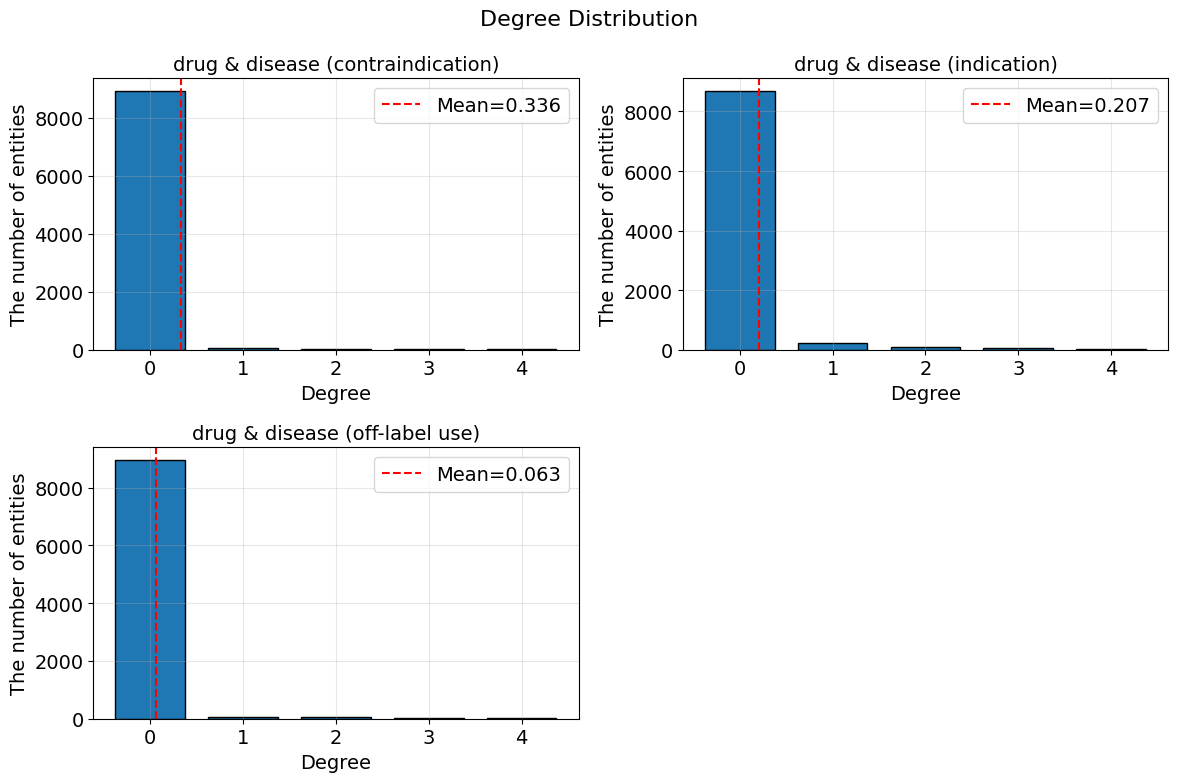

In [75]:
plt.rcParams.update({'font.size': 14})

fig = plt.figure(figsize=(12, 8))
fig.suptitle('Degree Distribution', fontsize=16)

gs = fig.add_gridspec(2, 2)
axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0])
]

relation_types = ['contraindication', 'indication', 'off-label use']

for idx, title in enumerate(relation_types):
    values = list(relations_df[title].to_dict().values())
    print(f"{title} count: {len(values)}")
    
    mean_value = np.mean(values)
    print(f"{title} mean_value: {mean_value}")
    
    value_counts = pd.Series(values).value_counts().sort_index()
    degrees = list(range(0, 5))
    counts = [value_counts.get(d, 0) for d in degrees]
    
    ax = axes[idx]
    ax.bar(degrees, counts, edgecolor='black', width=0.75)
    
    ax.axvline(x=mean_value, color='red', linestyle='--', label=f'Mean={round(mean_value, 3)}')
    
    ax.set_title(f'drug & disease ({title})', fontsize=14)
    ax.set_xlabel('Degree', fontsize=14)
    ax.set_ylabel('The number of entities', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=14)
    
    ax.set_xticks(range(0, 5, 1))
    
plt.tight_layout()  # 自动调整子图布局
plt.savefig('../../papers/figures/primekg_orphanet_degree_distribution_drug_disease.png', 
            bbox_inches='tight', dpi=300)
plt.show()